In [4]:
import pandas as pd
import numpy as np

# Setting seed for reproducibility
np.random.seed(42)

# Parameters
n_users = 20000
control_mean = 120 # 120 minutes of watch time
variant_mean = 128 # The "Long Preview" group watches slightly more
std_dev = 40

# Generating Data
data = pd.DataFrame({
    'user_id': range(1, n_users + 1),
    'group': np.random.choice(['control', 'variant'], size=n_users),
})

# Simulating watch time based on group
data['watch_time'] = np.where(
    data['group'] == 'control',
    np.random.normal(control_mean, std_dev, n_users),
    np.random.normal(variant_mean, std_dev, n_users)
)

# Ensuring no negative watch time
data['watch_time'] = data['watch_time'].clip(lower=0)

if not os.path.exists('data'):
    os.makedirs('data')

# Exporting to CSV
data.to_csv('data/raw_engagement_data.csv', index=False)

print(data.head())

   user_id    group  watch_time
0        1  control   60.485532
1        2  variant  128.301545
2        3  control  135.552756
3        4  control   73.045067
4        5  control  164.505372


In [2]:
from scipy import stats

# Separating the groups
control_group = data[data['group'] == 'control']['watch_time']
variant_group = data[data['group'] == 'variant']['watch_time']

# Calculating means
mean_c = control_group.mean()
mean_v = variant_group.mean()
lift = (mean_v - mean_c) / mean_c

# Running the T-Test
t_stat, p_val = stats.ttest_ind(control_group, variant_group)

print(f"Control Mean: {mean_c:.2f} mins")
print(f"Variant Mean: {mean_v:.2f} mins")
print(f"Lift: {lift:.2%}")
print(f"P-Value: {p_val:.4f}")


Control Mean: 119.82 mins
Variant Mean: 128.41 mins
Lift: 7.17%
P-Value: 0.0000


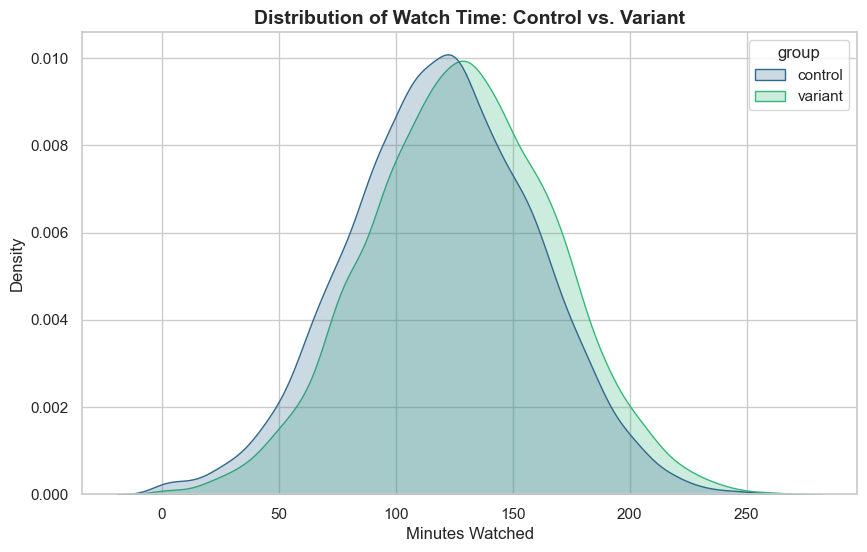

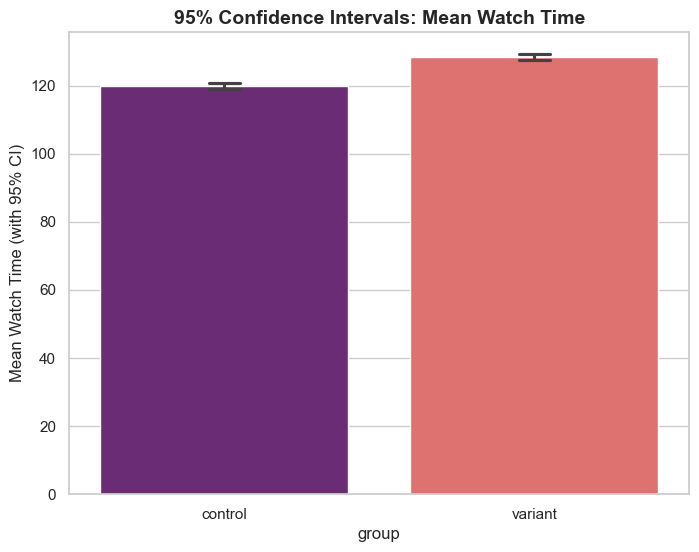

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 1. KDE Plot (watch_time_distribution.png)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='watch_time', hue='group', fill=True, palette='viridis', common_norm=False)
plt.title('Distribution of Watch Time: Control vs. Variant', fontsize=14, fontweight='bold')
plt.xlabel('Minutes Watched')
plt.ylabel('Density')
plt.savefig('visuals/watch_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Confidence Interval Bar Chart (confidence_intervals_bar.png)
plt.figure(figsize=(8, 6))
# Using errorbar='ci' calculates the 95% Confidence Interval automatically
sns.barplot(
    x='group', 
    y='watch_time', 
    data=data, 
    errorbar=('ci', 95), 
    palette='magma', 
    hue='group', 
    legend=False,
    capsize=.1
)
plt.title('95% Confidence Intervals: Mean Watch Time', fontsize=14, fontweight='bold')
plt.ylabel('Mean Watch Time (with 95% CI)')
plt.savefig('visuals/confidence_intervals_bar.png', dpi=300, bbox_inches='tight')
plt.show()